In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adnan9299/churm-model/Churn_Modelling.csv


In [1]:
#Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
#load the dataset
df = pd.read_csv('/kaggle/input/datasets/adnan9299/churm-model/Churn_Modelling.csv')


Understanding the dataset

In [5]:
df.shape

(10000, 14)

In [6]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Some columns need to be dropped such as Rownumber, CustomerId, Surname as they have no predictive value. While gender and geography will be encoded. 

In [7]:
print(df['Exited'].value_counts(normalize=True))   # check class

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


We have a ~80/20 class imbalance. If we leave it be, our model can reach 79.6% accuracy by just predicting "Stayed" for everyone.

To solve this class imbalance we will use (The class_weight='balanced') in Random Forest to automatically adjust it.

In [8]:
#check for missing values 
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
print(df.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
#Dropping columns with no predictive value
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [15]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


The dataset contains 10,000 customer records with no missing numerical values. Customers have an average credit score of 650, average age of 39 years, and average tenure of 5 years, showing a mix of new and long-term customers. Around 70% own a credit card and 51% are active members. The churn rate is 20.4%, indicating class imbalance with most customers staying. Balance and salary show high variation, suggesting customer financial status differs significantly across the dataset.

Visualization


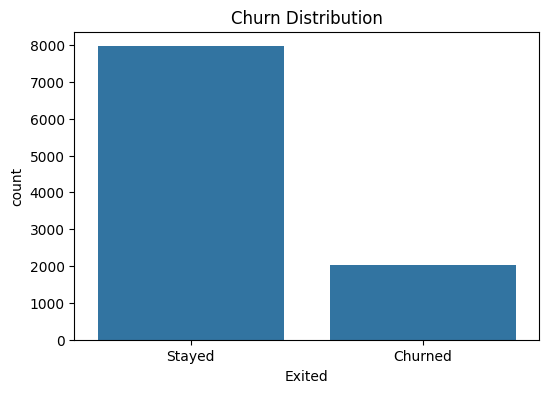

In [16]:
import seaborn as sns
# 5. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.xticks([0,1], ['Stayed','Churned'])
plt.show()

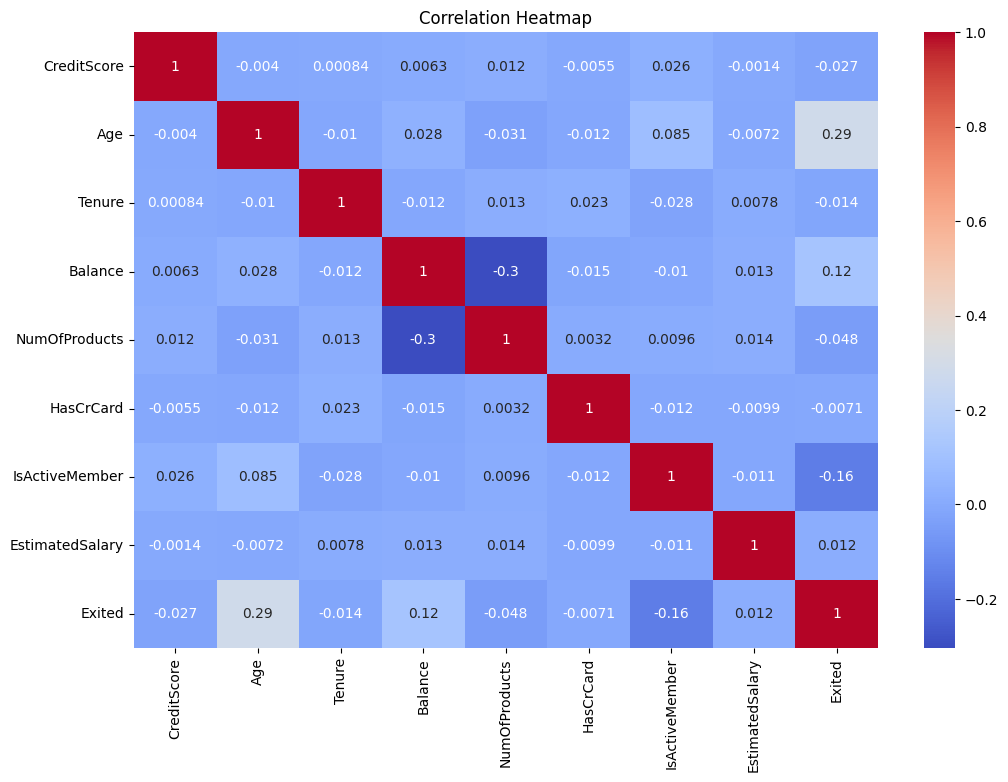

In [17]:
# 7. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Categorical Analysis

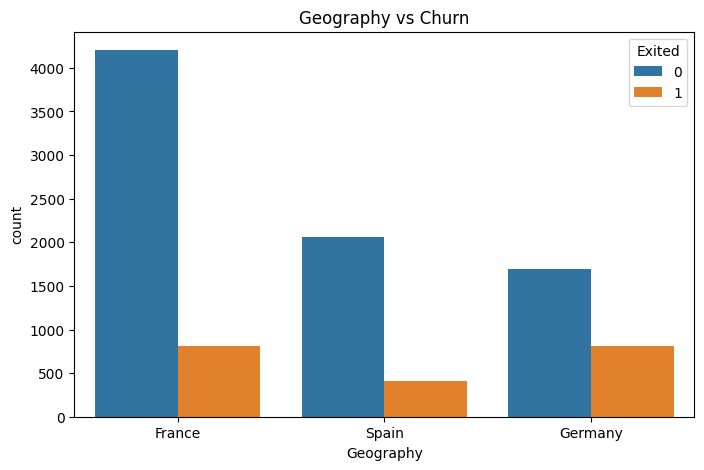

In [18]:
# Geography vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn")
plt.show()

France and Spain have similar customer bases and nearly identical churn rates. Germany is dramatically different. it has fewer total customers than France but almost the same number of churners, pushing its churn rate to roughly double that of the other two countries.
The bank should investigate whether it's a pricing issue, service quality, local competition, or product-market fit specific to German customers and invest in targeted retention strategies .

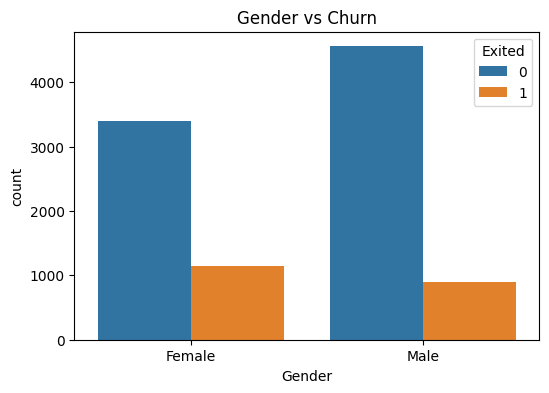

In [19]:
# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Churn")
plt.show()

There are more Male customers than Female, but the female churn rate is higher than that of males, Bank should look for strategies to retain their female customers

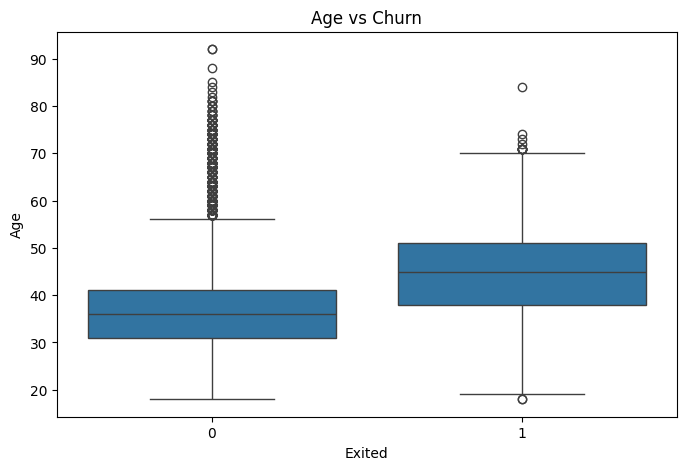

In [20]:
# Age impact
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

Encode categorical features

In [25]:
# Label Encoding for binary Gender column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

In [ ]:
# One-Hot Encoding for Geography (3 categories)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [27]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [34]:
#Split the dataset
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class ratio
)

# Scale numeric features (important for distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test) 

Train the classifier

In [35]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles the ~80/20 class imbalance
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Evaluate 

In [30]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



The model performs excellently at identifying customers who will stay, achieving a precision of 0.87, recall of 0.97. This means nearly all customers predicted to stay do in fact stay, and very few actual non-churners are missed.
Performance on the minority class(Class 1)is moderate. The model achieves a precision of 0.79, meaning that when it flags a customer as likely to churn, it is correct 79% of the time. However, recall stands at only 0.44. the model misses 56% of actual churners.

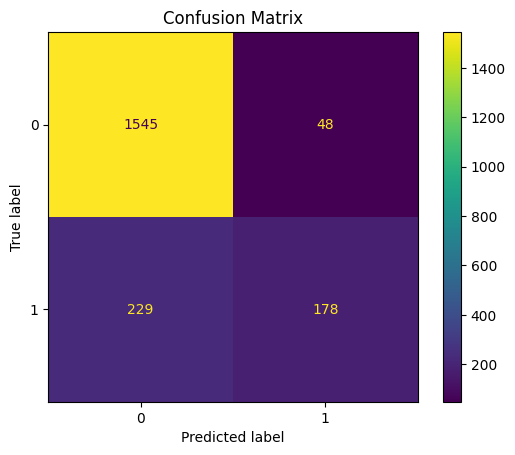

In [31]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

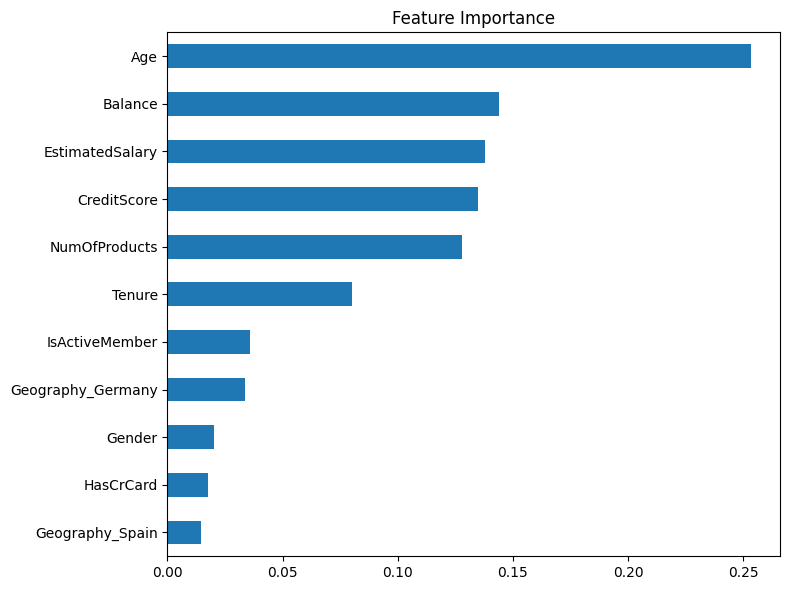

In [32]:
# Feature importance bar chart
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

Conclusion:
Feature importance analysis from the Random Forest model reveals that Age is the single strongest predictor of churn, followed by Balance, EstimatedSalary, CreditScore, and NumOfProducts. Behavioral indicators such as IsActiveMember and geographic signals like Geography_Germany contribute meaningfully but at a lower magnitude. Gender carries the least predictive power. These findings suggest that churn is primarily driven by customer life stage and financial profile rather than engagement behavior alone, and that retention strategies should prioritize middle-aged, high-balance customers with limited product holdings.